In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, StratifiedKFold, cross_val_score

# 1. Import database

In [68]:
url = "https://raw.githubusercontent.com/diogenesjusto/FIAP/master/dados/credit.csv"

# Importa Base, separação por tabulação
base = pd.read_csv(url, sep="\t", encoding="Latin-1")

# Cria uma lista com os nomes das colunas
header = ['ID_CLIENTE', 'TIPO_FUNCIONARIO', 'DIA_PAGAMENTO', 'TIPO_ENVIO_APLICACAO', 'QUANT_CARTOES_ADICIONAIS',
          'TIPO_ENDERECO_POSTAL', 'SEXO', 'ESTADO_CIVIL', 'QUANT_DEPENDENTES', 'NIVEL_EDUCACIONAL', 'ESTADO_NASCIMENTO',
          'CIDADE_NASCIMENTO', 'NACIONALIDADE', 'ESTADO_RESIDENCIAL', 'CIDADE_RESIDENCIAL', 'BAIRRO_RESIDENCIAL',
          'FLAG_TELEFONE_RESIDENCIAL', 'CODIGO_AREA_TELEFONE_RESIDENCIAL', 'TIPO_RESIDENCIA', 'MESES_RESIDENCIA',
          'FLAG_TELEFONE_MOVEL', 'FLAG_EMAIL', 'RENDA_PESSOAL_MENSAL', 'OUTRAS_RENDAS', 'FLAG_VISA', 'FLAG_MASTERCARD',
          'FLAG_DINERS', 'FLAG_AMERICAN_EXPRESS', 'FLAG_OUTROS_CARTOES', 'QUANT_CONTAS_BANCARIAS',
          'QUANT_CONTAS_BANCARIAS_ESPECIAIS', 'VALOR_PATRIMONIO_PESSOAL', 'QUANT_CARROS', 'EMPRESA',
          'ESTADO_PROFISSIONAL', 'CIDADE_PROFISSIONAL', 'BAIRRO_PROFISSIONAL', 'FLAG_TELEFONE_PROFISSIONAL',
          'CODIGO_AREA_TELEFONE_PROFISSIONAL', 'MESES_NO_TRABALHO', 'CODIGO_PROFISSAO', 'TIPO_OCUPACAO',
          'CODIGO_PROFISSAO_CONJUGE', 'NIVEL_EDUCACIONAL_CONJUGE', 'FLAG_DOCUMENTO_RESIDENCIAL', 'FLAG_RG',
          'FLAG_CPF', 'FLAG_COMPROVANTE_RENDA', 'PRODUTO', 'FLAG_REGISTRO_ACSP', 'IDADE', 'CEP_RESIDENCIAL_3',
          'CEP_PROFISSIONAL_3', 'ROTULO_ALVO_MAU=1'
]
 
# Adiciona nome as colunas do data frame
base.columns = header
base

C:\Users\ivan_\AppData\Local\Temp\ipykernel_32276\1077767996.py:4: DtypeWarning: Columns (51,52) have mixed types. Specify dtype option on import or set low_memory=False.
  base = pd.read_csv(url, sep="\t", encoding="Latin-1")


,ID_CLIENTE,TIPO_FUNCIONARIO,DIA_PAGAMENTO,TIPO_ENVIO_APLICACAO,QUANT_CARTOES_ADICIONAIS,TIPO_ENDERECO_POSTAL,SEXO,ESTADO_CIVIL,QUANT_DEPENDENTES,NIVEL_EDUCACIONAL,...,FLAG_DOCUMENTO_RESIDENCIAL,FLAG_RG,FLAG_CPF,FLAG_COMPROVANTE_RENDA,PRODUTO,FLAG_REGISTRO_ACSP,IDADE,CEP_RESIDENCIAL_3,CEP_PROFISSIONAL_3,ROTULO_ALVO_MAU=1
0,2,C,15,Carga,0,1,F,2,0,0,...,0,0,0,0,1,N,34,230,230,1
1,3,C,5,Web,0,1,F,2,0,0,...,0,0,0,0,1,N,27,591,591,0
2,4,C,20,Web,0,1,F,2,0,0,...,0,0,0,0,1,N,61,545,545,0
3,5,C,10,Web,0,1,M,2,0,0,...,0,0,0,0,1,N,48,235,235,1
4,6,C,10,0,0,1,M,2,0,0,...,0,0,0,0,2,N,40,371,371,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49994,49996,C,10,0,0,1,F,1,2,0,...,0,0,0,0,1,N,36,591,591,1
49995,49997,C,25,0,0,1,F,1,0,0,...,0,0,0,0,2,N,21,186,186,0
49996,49998,C,5,Web,0,1,M,2,3,0,...,0,0,0,0,1,N,41,715,715,0
49997,49999,C,1,Web,0,1,F,1,1,0,...,0,0,0,0,1,N,28,320,320,1


In [69]:
base.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49999 entries, 0 to 49998
Data columns (total 54 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   ID_CLIENTE                         49999 non-null  int64  
 1   TIPO_FUNCIONARIO                   49999 non-null  object 
 2   DIA_PAGAMENTO                      49999 non-null  int64  
 3   TIPO_ENVIO_APLICACAO               49999 non-null  object 
 4   QUANT_CARTOES_ADICIONAIS           49999 non-null  int64  
 5   TIPO_ENDERECO_POSTAL               49999 non-null  int64  
 6   SEXO                               49999 non-null  object 
 7   ESTADO_CIVIL                       49999 non-null  int64  
 8   QUANT_DEPENDENTES                  49999 non-null  int64  
 9   NIVEL_EDUCACIONAL                  49999 non-null  int64  
 10  ESTADO_NASCIMENTO                  49999 non-null  object 
 11  CIDADE_NASCIMENTO                  49999 non-null  obj

In [70]:
base.describe()

,ID_CLIENTE,DIA_PAGAMENTO,QUANT_CARTOES_ADICIONAIS,TIPO_ENDERECO_POSTAL,ESTADO_CIVIL,QUANT_DEPENDENTES,NIVEL_EDUCACIONAL,NACIONALIDADE,TIPO_RESIDENCIA,MESES_RESIDENCIA,...,TIPO_OCUPACAO,CODIGO_PROFISSAO_CONJUGE,NIVEL_EDUCACIONAL_CONJUGE,FLAG_DOCUMENTO_RESIDENCIAL,FLAG_RG,FLAG_CPF,FLAG_COMPROVANTE_RENDA,PRODUTO,IDADE,ROTULO_ALVO_MAU=1
count,49999.000000,49999.000000,49999.0,49999.000000,49999.000000,49999.000000,49999.0,49999.000000,48650.000000,46222.000000,...,42686.000000,21116.000000,17662.000000,49999.0,49999.0,49999.0,49999.0,49999.000000,49999.000000,49999.000000
mean,25001.000000,12.870077,0.0,1.006540,2.148323,0.650513,0.0,0.961599,1.252230,9.727035,...,2.484281,3.797926,0.296003,0.0,0.0,0.0,0.0,1.275706,43.248745,0.260805
std,14433.612391,6.608357,0.0,0.080607,1.322751,1.193666,0.0,0.202107,0.867841,10.668928,...,1.532262,5.212168,0.955688,0.0,0.0,0.0,0.0,0.988295,14.989115,0.439078
min,2.000000,1.000000,0.0,1.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,1.000000,6.000000,0.000000
25%,12501.500000,10.000000,0.0,1.000000,1.000000,0.000000,0.0,1.000000,1.000000,1.000000,...,1.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,1.000000,31.000000,0.000000
50%,25001.000000,10.000000,0.0,1.000000,2.000000,0.000000,0.0,1.000000,1.000000,6.000000,...,2.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,1.000000,41.000000,0.000000
75%,37500.500000,15.000000,0.0,1.000000,2.000000,1.000000,0.0,1.000000,1.000000,15.000000,...,4.000000,11.000000,0.000000,0.0,0.0,0.0,0.0,1.000000,53.000000,1.000000
max,50000.000000,25.000000,0.0,2.000000,7.000000,53.000000,0.0,2.000000,5.000000,228.000000,...,5.000000,17.000000,5.000000,0.0,0.0,0.0,0.0,7.000000,106.000000,1.000000


In [71]:
base["TIPO_ENVIO_APLICACAO"].value_counts()

TIPO_ENVIO_APLICACAO
Web      28205
0        19461
Carga     2333
Name: count, dtype: int64

In [72]:
base["QUANT_CARTOES_ADICIONAIS"].value_counts()

QUANT_CARTOES_ADICIONAIS
0    49999
Name: count, dtype: int64

In [73]:
base["TIPO_ENDERECO_POSTAL"].value_counts()

TIPO_ENDERECO_POSTAL
1    49672
2      327
Name: count, dtype: int64

In [74]:
base["ESTADO_CIVIL"].value_counts()

ESTADO_CIVIL
2    25967
1    15286
4     4206
6     1876
5     1296
3      632
7      534
0      202
Name: count, dtype: int64

In [75]:
base["QUANT_DEPENDENTES"].value_counts()

QUANT_DEPENDENTES
0     33655
1      7003
2      5363
3      2465
4       860
5       365
6       139
7        65
8        35
9        14
10       13
11        7
12        6
13        4
14        3
15        1
53        1
Name: count, dtype: int64

In [76]:
base["NIVEL_EDUCACIONAL"].value_counts()

NIVEL_EDUCACIONAL
0    49999
Name: count, dtype: int64

In [77]:
base["NACIONALIDADE"].value_counts()

NACIONALIDADE
1    47883
0     2018
2       98
Name: count, dtype: int64

In [78]:
base["MESES_RESIDENCIA"].value_counts()

MESES_RESIDENCIA
1.0      7340
0.0      4695
10.0     3799
5.0      3561
2.0      3217
         ... 
101.0       1
66.0        1
78.0        1
81.0        1
89.0        1
Name: count, Length: 88, dtype: int64

In [79]:
base["QUANT_CONTAS_BANCARIAS"].value_counts()

QUANT_CONTAS_BANCARIAS
0    32121
1    17864
2       14
Name: count, dtype: int64

In [80]:
base["QUANT_CONTAS_BANCARIAS_ESPECIAIS"].value_counts()

QUANT_CONTAS_BANCARIAS_ESPECIAIS
0    32121
1    17864
2       14
Name: count, dtype: int64

In [81]:
base["VALOR_PATRIMONIO_PESSOAL"].value_counts()

VALOR_PATRIMONIO_PESSOAL
0.0          47608
30000.0        222
25000.0        198
50000.0        196
15000.0        185
             ...  
5000000.0        1
220000.0         1
53000.0          1
401.0            1
10500.0          1
Name: count, Length: 153, dtype: int64

In [82]:
base["QUANT_CARROS"].value_counts()

QUANT_CARROS
0    33192
1    16807
Name: count, dtype: int64

In [83]:
base["CODIGO_PROFISSAO"].value_counts()

CODIGO_PROFISSAO
9.0     30091
11.0     3545
0.0      3540
2.0      2827
12.0      489
10.0      425
16.0      344
13.0      313
7.0       216
8.0       144
6.0       136
15.0       63
17.0       35
4.0        27
3.0        18
5.0        12
14.0        9
1.0         8
18.0        1
Name: count, dtype: int64

In [84]:
base["TIPO_OCUPACAO"].value_counts()

TIPO_OCUPACAO
2.0    16947
1.0     8742
4.0     6999
5.0     6891
0.0     2788
3.0      319
Name: count, dtype: int64

In [85]:
base["FLAG_COMPROVANTE_RENDA"].value_counts()

FLAG_COMPROVANTE_RENDA
0    49999
Name: count, dtype: int64

In [86]:
base['MESES_NO_TRABALHO'].value_counts()

MESES_NO_TRABALHO
0     49923
2        18
1        15
3        12
5         6
4         4
6         2
14        2
12        2
7         2
18        2
8         2
9         1
30        1
10        1
27        1
19        1
15        1
32        1
35        1
26        1
Name: count, dtype: int64

In [87]:
base["QUANT_CARROS"].value_counts()

QUANT_CARROS
0    33192
1    16807
Name: count, dtype: int64

In [88]:
base["PRODUTO"].value_counts()

PRODUTO
1    42689
2     6015
7     1295
Name: count, dtype: int64

In [89]:
base["TEM_CARTAO"] = base[['FLAG_VISA',
                                'FLAG_MASTERCARD',
                                'FLAG_DINERS',
                                'FLAG_AMERICAN_EXPRESS', 
                                'FLAG_OUTROS_CARTOES']].any(axis=1)
base["TEM_CARTAO"].value_counts()

TEM_CARTAO
False    41804
True      8195
Name: count, dtype: int64

In [90]:
base["NIVEL_EDUCACIONAL"].value_counts()

NIVEL_EDUCACIONAL
0    49999
Name: count, dtype: int64

In [91]:
base["RENDA_TOTAL"] = base["RENDA_PESSOAL_MENSAL"] + base["OUTRAS_RENDAS"]
base["RENDA_TOTAL"].describe()

count     49999.000000
mean        922.113639
std        7897.548056
min          60.000000
25%         372.000000
50%         515.000000
75%         839.500000
max      959000.000000
Name: RENDA_TOTAL, dtype: float64

In [92]:
lista_drop_features=[
    "ID_CLIENTE",
    "TIPO_FUNCIONARIO",
    "DIA_PAGAMENTO",
    "TIPO_ENVIO_APLICACAO",
    "QUANT_CARTOES_ADICIONAIS",
    "TIPO_ENDERECO_POSTAL",
    "NIVEL_EDUCACIONAL",
    "ESTADO_NASCIMENTO",
    "CIDADE_NASCIMENTO",
    "NACIONALIDADE",
    "ESTADO_RESIDENCIAL",
    "CIDADE_RESIDENCIAL",
    "BAIRRO_RESIDENCIAL",
    "BAIRRO_PROFISSIONAL",
    "FLAG_TELEFONE_RESIDENCIAL",
    "CODIGO_AREA_TELEFONE_RESIDENCIAL",
    "MESES_RESIDENCIA",
    "FLAG_TELEFONE_MOVEL",
    "FLAG_EMAIL",
    "QUANT_CONTAS_BANCARIAS_ESPECIAIS",
    "VALOR_PATRIMONIO_PESSOAL",
    #"QUANT_CARROS",
    "EMPRESA",
    "ESTADO_PROFISSIONAL",
    "CIDADE_PROFISSIONAL",
    "BAIRRO_PROFISSIONAL",
    "FLAG_TELEFONE_PROFISSIONAL",
    "CODIGO_AREA_TELEFONE_PROFISSIONAL",
    #"MESES_NO_TRABALHO",
    "CODIGO_PROFISSAO",
    "CODIGO_PROFISSAO_CONJUGE",
    "NIVEL_EDUCACIONAL_CONJUGE",
    "FLAG_DOCUMENTO_RESIDENCIAL",
    "FLAG_RG",
    "FLAG_CPF",
    "FLAG_COMPROVANTE_RENDA",
    "FLAG_REGISTRO_ACSP",
    "CEP_RESIDENCIAL_3",
    "CEP_PROFISSIONAL_3",
    "QUANT_CONTAS_BANCARIAS",
    'FLAG_VISA',
    'FLAG_MASTERCARD',
    'FLAG_DINERS',
    'FLAG_AMERICAN_EXPRESS', 
    'FLAG_OUTROS_CARTOES',
    "RENDA_PESSOAL_MENSAL", 
    "OUTRAS_RENDAS",
    ]

In [93]:
base = base.drop(columns=lista_drop_features)

In [94]:
base.isnull().sum()

SEXO                    0
ESTADO_CIVIL            0
QUANT_DEPENDENTES       0
TIPO_RESIDENCIA      1349
QUANT_CARROS            0
MESES_NO_TRABALHO       0
TIPO_OCUPACAO        7313
PRODUTO                 0
IDADE                   0
ROTULO_ALVO_MAU=1       0
TEM_CARTAO              0
RENDA_TOTAL             0
dtype: int64

# 2. Tratamentos dos dados

In [95]:
base.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49999 entries, 0 to 49998
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   SEXO               49999 non-null  object 
 1   ESTADO_CIVIL       49999 non-null  int64  
 2   QUANT_DEPENDENTES  49999 non-null  int64  
 3   TIPO_RESIDENCIA    48650 non-null  float64
 4   QUANT_CARROS       49999 non-null  int64  
 5   MESES_NO_TRABALHO  49999 non-null  int64  
 6   TIPO_OCUPACAO      42686 non-null  float64
 7   PRODUTO            49999 non-null  int64  
 8   IDADE              49999 non-null  int64  
 9   ROTULO_ALVO_MAU=1  49999 non-null  int64  
 10  TEM_CARTAO         49999 non-null  bool   
 11  RENDA_TOTAL        49999 non-null  float64
dtypes: bool(1), float64(3), int64(7), object(1)
memory usage: 4.2+ MB


In [96]:
base["RENDA_TOTAL"].describe()

count     49999.000000
mean        922.113639
std        7897.548056
min          60.000000
25%         372.000000
50%         515.000000
75%         839.500000
max      959000.000000
Name: RENDA_TOTAL, dtype: float64

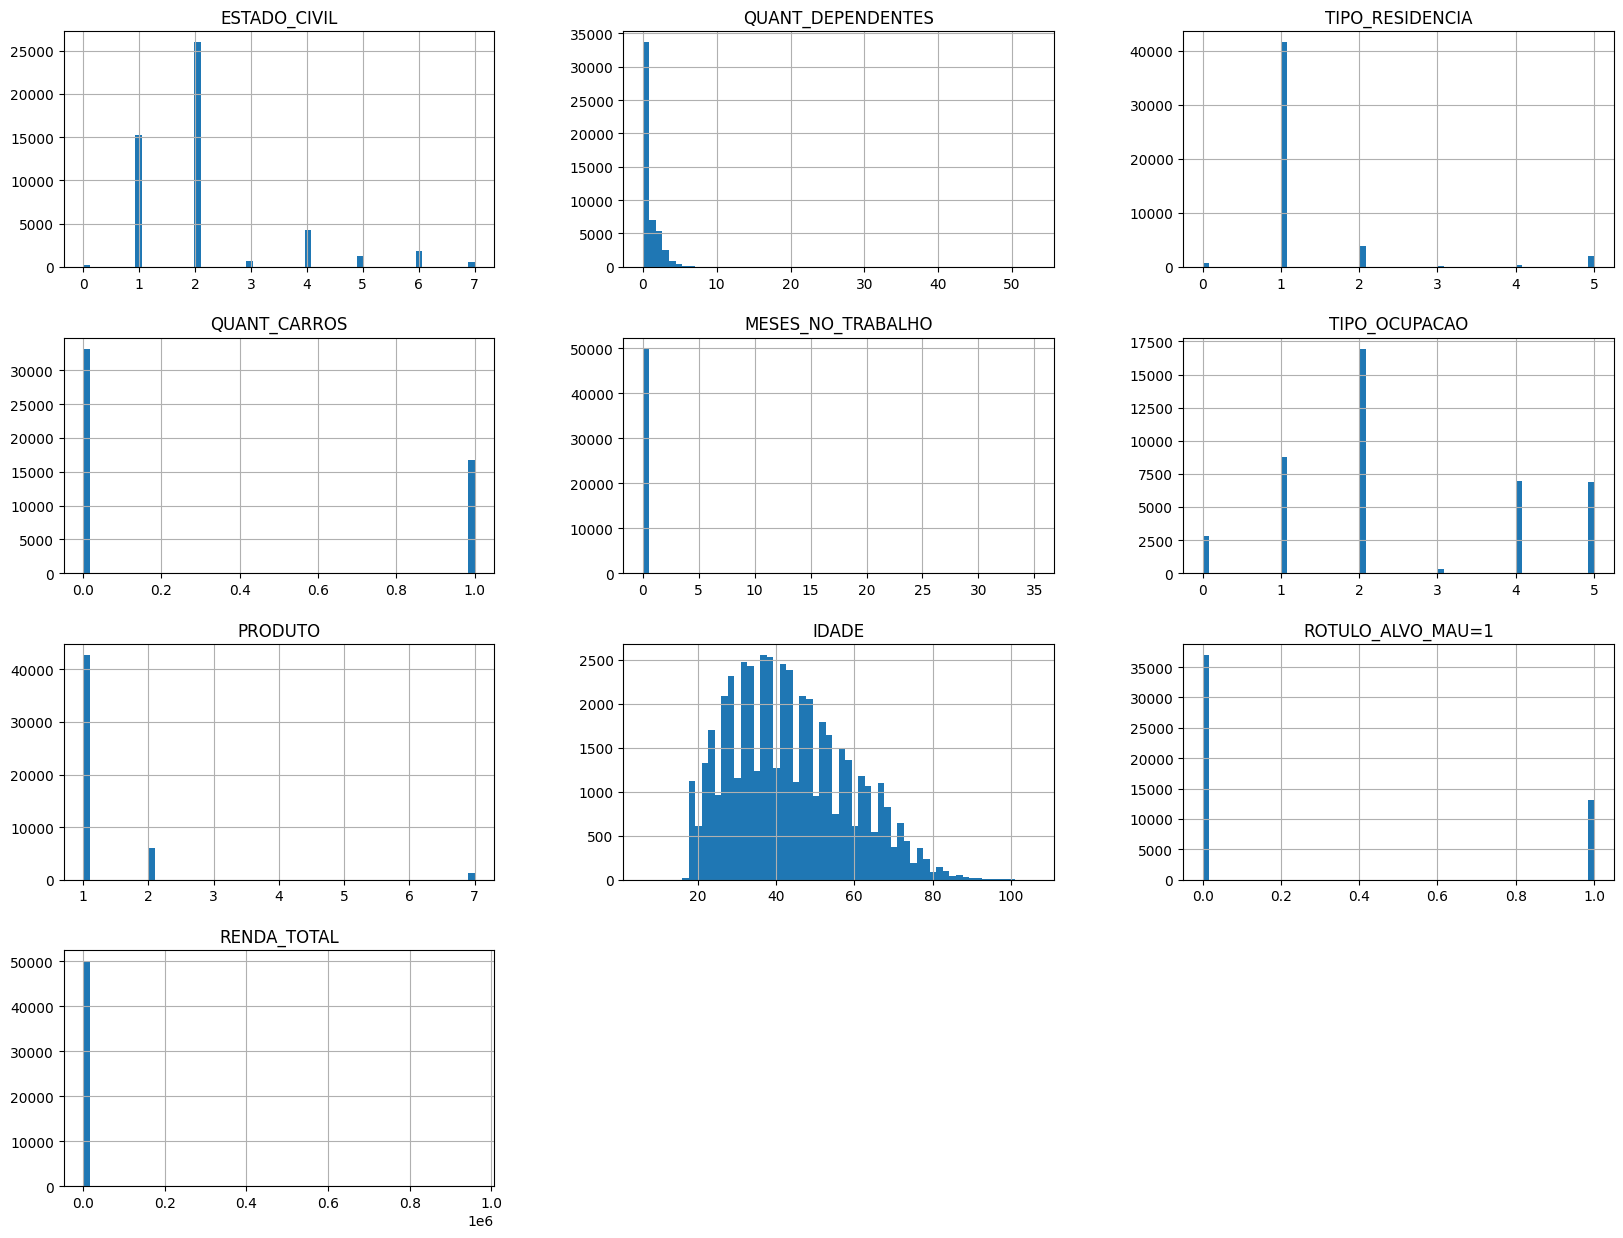

In [97]:
base.hist(bins=60, figsize=(20,15));

Text(0, 0.5, 'Qte_dependentes')

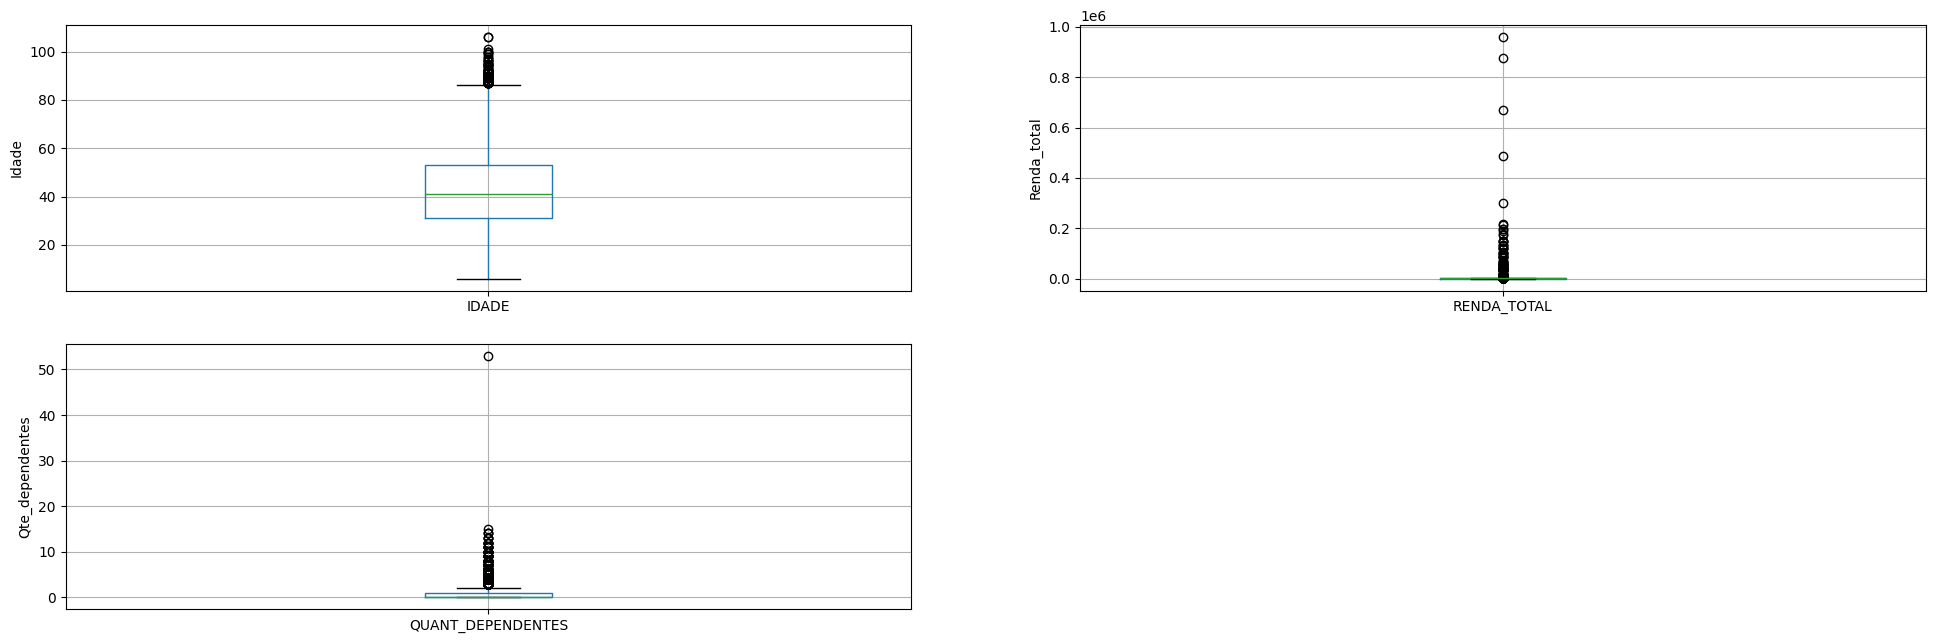

In [98]:
plt.figure(figsize=(24,20))

plt.subplot(5, 2, 1)
fig = base.boxplot(column='IDADE')
fig.set_title('')
fig.set_ylabel('Idade')

plt.subplot(5, 2, 2)
fig = base.boxplot(column='RENDA_TOTAL')
fig.set_title('')
fig.set_ylabel('Renda_total')

plt.subplot(5, 2, 3)
fig = base.boxplot(column='QUANT_DEPENDENTES')
fig.set_title('')
fig.set_ylabel('Qte_dependentes')

In [99]:
base["QUANT_DEPENDENTES"] = base["QUANT_DEPENDENTES"].apply(lambda x: 7 if x > 7 else x)
base['QUANT_DEPENDENTES'].value_counts()

QUANT_DEPENDENTES
0    33655
1     7003
2     5363
3     2465
4      860
5      365
7      149
6      139
Name: count, dtype: int64

In [100]:
#base['IDADE'] = base['IDADE'].apply(lambda x: 85 if x > 85 else x)
#base['IDADE'].value_counts()

base['IDADE'] = pd.cut(base['IDADE'],
                       bins=[0, 18, 25, 35, 45, 55, 65, 80, np.inf],
                       labels=[0, 1, 2, 3, 4, 5, 6, 7]).astype(int)

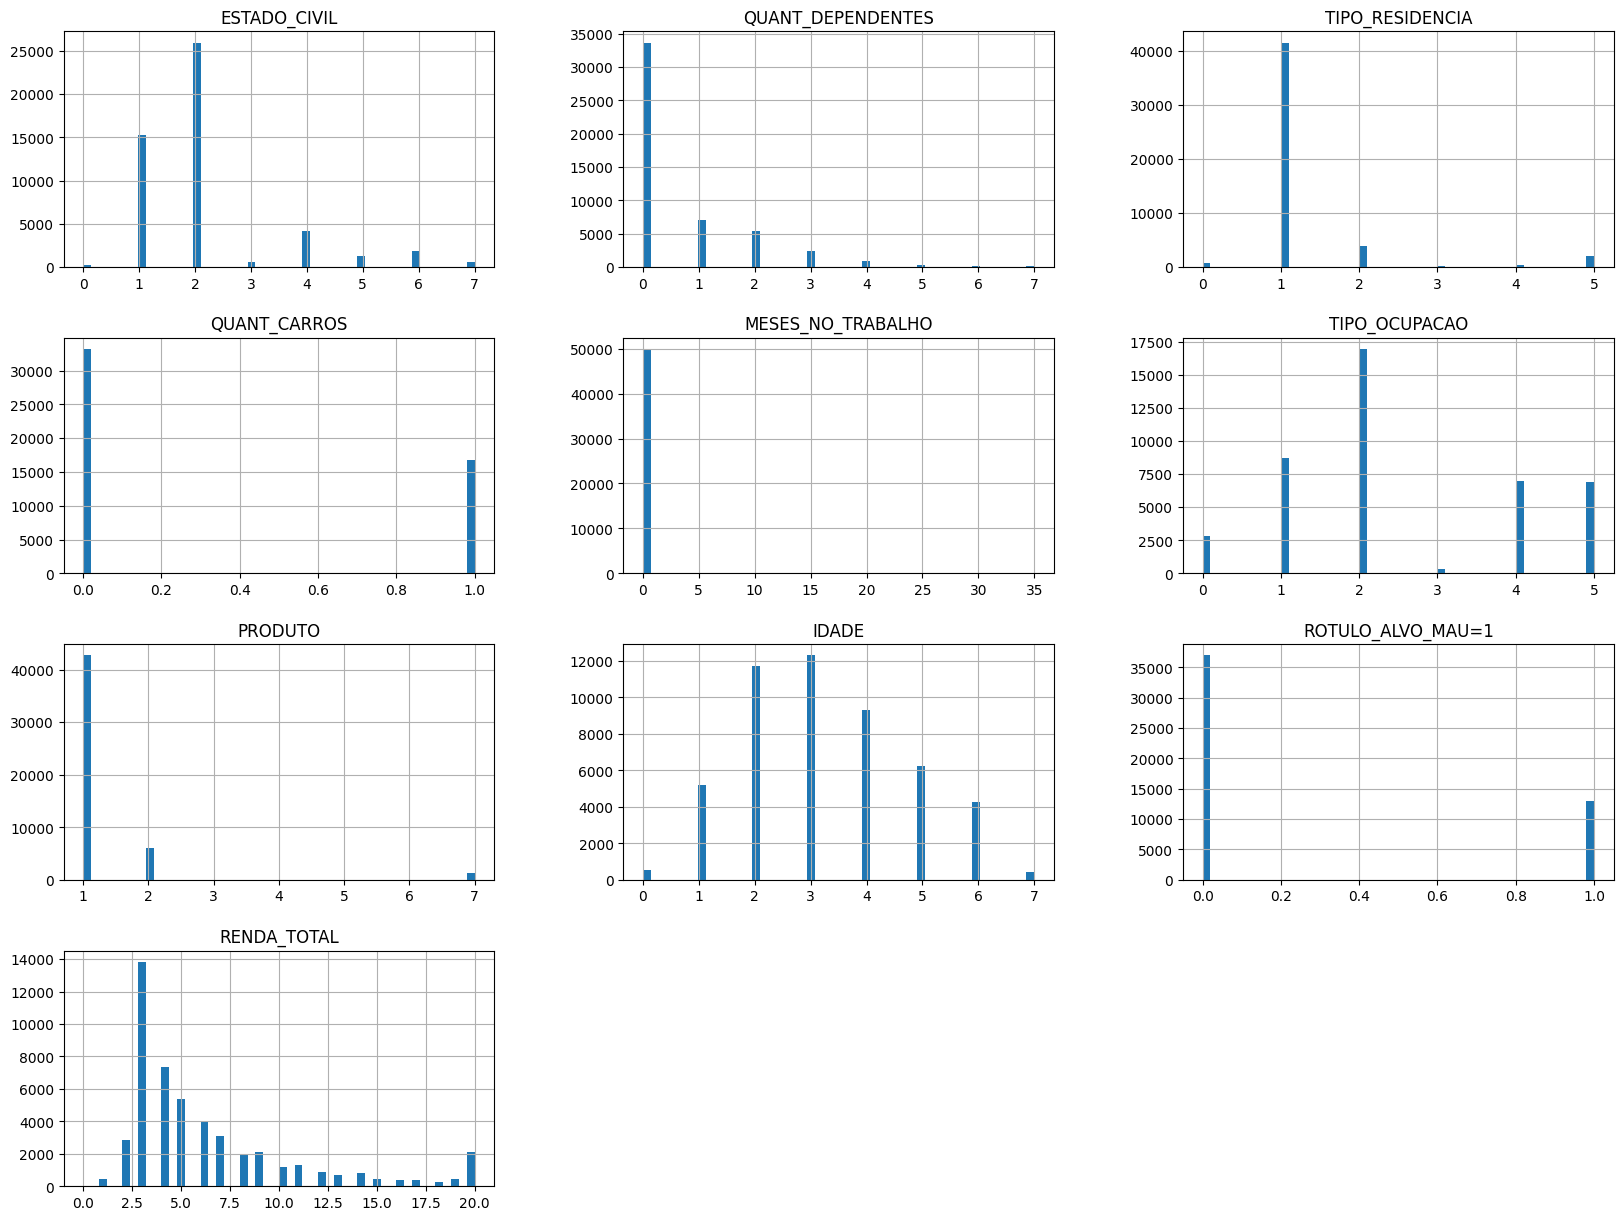

In [101]:
#base["RENDA_TOTAL"] = base["RENDA_TOTAL"].apply(lambda x: 2000 if x > 2000 else x)
#base['RENDA_TOTAL'].describe()

base['RENDA_TOTAL'] = pd.cut(base['RENDA_TOTAL'],
                       bins=[0, 100., 200., 300., 400., 500., 600., 700., 800., 900., 1000., 1100., 1200., 1300., 1400., 1500., 1600., 1700., 1800., 1900., 2000., np.inf],
                       labels=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]).astype(int)
#base.info()
#base['RENDA_TOTAL1'].value_counts()
base.hist(bins=50, figsize=(20,15));
#base.info()
#teste = base[['RENDA_TOTAL', 'RENDA_TOTAL1']]
#teste[teste['RENDA_TOTAL1'].isna()]


Text(0, 0.5, 'Qtd_dependentes')

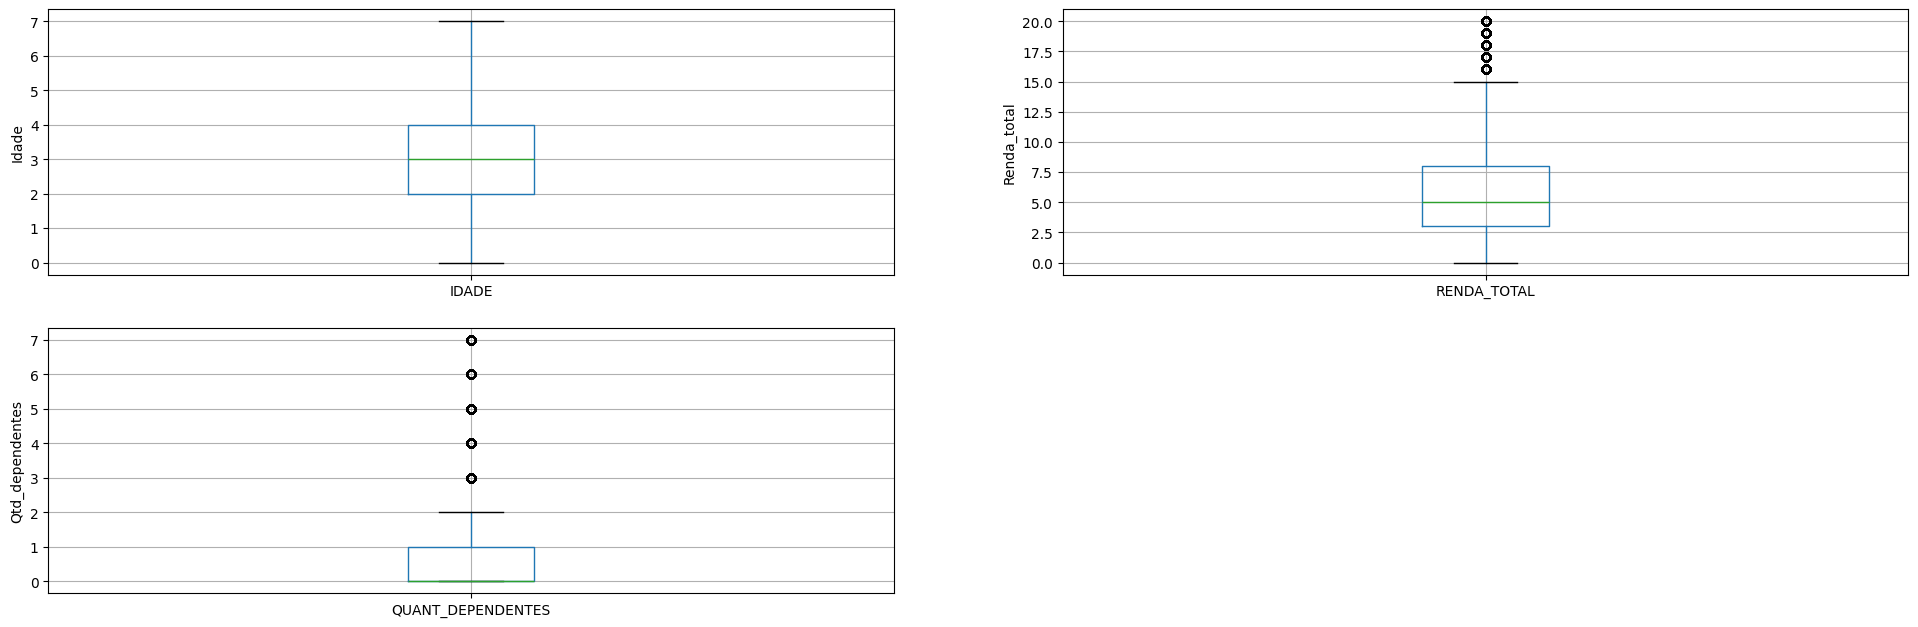

In [134]:
plt.figure(figsize=(24,20))

plt.subplot(5, 2, 1)
fig = base.boxplot(column='IDADE')
fig.set_title('')
fig.set_ylabel('Idade')

plt.subplot(5, 2, 2)
fig = base.boxplot(column='RENDA_TOTAL')
fig.set_title('')
fig.set_ylabel('Renda_total')

plt.subplot(5, 2, 3)
fig = base.boxplot(column='QUANT_DEPENDENTES')
fig.set_title('')
fig.set_ylabel('Qtd_dependentes')

## 2.1 Separação das bases

In [103]:
base_numerica = base.select_dtypes(exclude=['object'])
base_objeto = base.select_dtypes(exclude=['int64', 'float64'])

In [104]:
base_objeto.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49999 entries, 0 to 49998
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   SEXO        49999 non-null  object
 1   TEM_CARTAO  49999 non-null  bool  
dtypes: bool(1), object(1)
memory usage: 439.6+ KB


## 2.1 SEXO

In [105]:
sexo = pd.get_dummies(base_objeto['SEXO'], drop_first=True)
sexo.head()

,F,M,N
0,True,False,False
1,True,False,False
2,True,False,False
3,False,True,False
4,False,True,False


In [106]:
base_numerica.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49999 entries, 0 to 49998
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ESTADO_CIVIL       49999 non-null  int64  
 1   QUANT_DEPENDENTES  49999 non-null  int64  
 2   TIPO_RESIDENCIA    48650 non-null  float64
 3   QUANT_CARROS       49999 non-null  int64  
 4   MESES_NO_TRABALHO  49999 non-null  int64  
 5   TIPO_OCUPACAO      42686 non-null  float64
 6   PRODUTO            49999 non-null  int64  
 7   IDADE              49999 non-null  int64  
 8   ROTULO_ALVO_MAU=1  49999 non-null  int64  
 9   TEM_CARTAO         49999 non-null  bool   
 10  RENDA_TOTAL        49999 non-null  int64  
dtypes: bool(1), float64(2), int64(8)
memory usage: 3.9 MB


# 3. Concatenando as bases

In [107]:
base_tratada = pd.concat([base_numerica],axis=1)
base_tratada.head()

,ESTADO_CIVIL,QUANT_DEPENDENTES,TIPO_RESIDENCIA,QUANT_CARROS,MESES_NO_TRABALHO,TIPO_OCUPACAO,PRODUTO,IDADE,ROTULO_ALVO_MAU=1,TEM_CARTAO,RENDA_TOTAL
0,2,0,1.0,0,0,4.0,1,2,1,False,7
1,2,0,1.0,0,0,NaN,1,2,0,False,4
2,2,0,NaN,0,0,NaN,1,5,0,False,4
3,2,0,1.0,0,0,5.0,1,4,1,False,11
4,2,0,1.0,1,0,2.0,2,3,1,False,4


In [108]:
base_tratada.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49999 entries, 0 to 49998
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ESTADO_CIVIL       49999 non-null  int64  
 1   QUANT_DEPENDENTES  49999 non-null  int64  
 2   TIPO_RESIDENCIA    48650 non-null  float64
 3   QUANT_CARROS       49999 non-null  int64  
 4   MESES_NO_TRABALHO  49999 non-null  int64  
 5   TIPO_OCUPACAO      42686 non-null  float64
 6   PRODUTO            49999 non-null  int64  
 7   IDADE              49999 non-null  int64  
 8   ROTULO_ALVO_MAU=1  49999 non-null  int64  
 9   TEM_CARTAO         49999 non-null  bool   
 10  RENDA_TOTAL        49999 non-null  int64  
dtypes: bool(1), float64(2), int64(8)
memory usage: 3.9 MB


# 4. Inputando dados

In [109]:
# mediana
median_imputer = SimpleImputer(strategy='median')
df_median = pd.DataFrame(median_imputer.fit_transform(base_tratada), columns=base_tratada.columns)

df_median

,ESTADO_CIVIL,QUANT_DEPENDENTES,TIPO_RESIDENCIA,QUANT_CARROS,MESES_NO_TRABALHO,TIPO_OCUPACAO,PRODUTO,IDADE,ROTULO_ALVO_MAU=1,TEM_CARTAO,RENDA_TOTAL
0,2.0,0.0,1.0,0.0,0.0,4.0,1.0,2.0,1.0,0.0,7.0
1,2.0,0.0,1.0,0.0,0.0,2.0,1.0,2.0,0.0,0.0,4.0
2,2.0,0.0,1.0,0.0,0.0,2.0,1.0,5.0,0.0,0.0,4.0
3,2.0,0.0,1.0,0.0,0.0,5.0,1.0,4.0,1.0,0.0,11.0
4,2.0,0.0,1.0,1.0,0.0,2.0,2.0,3.0,1.0,0.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...
49994,1.0,2.0,1.0,1.0,0.0,4.0,1.0,3.0,1.0,0.0,14.0
49995,1.0,0.0,1.0,0.0,0.0,2.0,2.0,1.0,0.0,0.0,4.0
49996,2.0,3.0,2.0,0.0,0.0,2.0,1.0,3.0,0.0,0.0,15.0
49997,1.0,1.0,1.0,0.0,0.0,2.0,1.0,2.0,1.0,0.0,14.0


In [110]:
# media
mean_imputer = SimpleImputer(strategy='mean')
df_mean = pd.DataFrame(mean_imputer.fit_transform(base_tratada), columns=base_tratada.columns)

df_mean

,ESTADO_CIVIL,QUANT_DEPENDENTES,TIPO_RESIDENCIA,QUANT_CARROS,MESES_NO_TRABALHO,TIPO_OCUPACAO,PRODUTO,IDADE,ROTULO_ALVO_MAU=1,TEM_CARTAO,RENDA_TOTAL
0,2.0,0.0,1.00000,0.0,0.0,4.000000,1.0,2.0,1.0,0.0,7.0
1,2.0,0.0,1.00000,0.0,0.0,2.484281,1.0,2.0,0.0,0.0,4.0
2,2.0,0.0,1.25223,0.0,0.0,2.484281,1.0,5.0,0.0,0.0,4.0
3,2.0,0.0,1.00000,0.0,0.0,5.000000,1.0,4.0,1.0,0.0,11.0
4,2.0,0.0,1.00000,1.0,0.0,2.000000,2.0,3.0,1.0,0.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...
49994,1.0,2.0,1.00000,1.0,0.0,4.000000,1.0,3.0,1.0,0.0,14.0
49995,1.0,0.0,1.00000,0.0,0.0,2.484281,2.0,1.0,0.0,0.0,4.0
49996,2.0,3.0,2.00000,0.0,0.0,2.000000,1.0,3.0,0.0,0.0,15.0
49997,1.0,1.0,1.00000,0.0,0.0,2.000000,1.0,2.0,1.0,0.0,14.0


In [111]:
# KNN Imputer
knn_imputer = KNNImputer(n_neighbors=2)
df_knn = pd.DataFrame(knn_imputer.fit_transform(base_tratada), columns=base_tratada.columns)

df_knn

,ESTADO_CIVIL,QUANT_DEPENDENTES,TIPO_RESIDENCIA,QUANT_CARROS,MESES_NO_TRABALHO,TIPO_OCUPACAO,PRODUTO,IDADE,ROTULO_ALVO_MAU=1,TEM_CARTAO,RENDA_TOTAL
0,2.0,0.0,1.0,0.0,0.0,4.0,1.0,2.0,1.0,0.0,7.0
1,2.0,0.0,1.0,0.0,0.0,2.0,1.0,2.0,0.0,0.0,4.0
2,2.0,0.0,1.5,0.0,0.0,3.5,1.0,5.0,0.0,0.0,4.0
3,2.0,0.0,1.0,0.0,0.0,5.0,1.0,4.0,1.0,0.0,11.0
4,2.0,0.0,1.0,1.0,0.0,2.0,2.0,3.0,1.0,0.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...
49994,1.0,2.0,1.0,1.0,0.0,4.0,1.0,3.0,1.0,0.0,14.0
49995,1.0,0.0,1.0,0.0,0.0,2.0,2.0,1.0,0.0,0.0,4.0
49996,2.0,3.0,2.0,0.0,0.0,2.0,1.0,3.0,0.0,0.0,15.0
49997,1.0,1.0,1.0,0.0,0.0,2.0,1.0,2.0,1.0,0.0,14.0


In [112]:
df_knn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49999 entries, 0 to 49998
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ESTADO_CIVIL       49999 non-null  float64
 1   QUANT_DEPENDENTES  49999 non-null  float64
 2   TIPO_RESIDENCIA    49999 non-null  float64
 3   QUANT_CARROS       49999 non-null  float64
 4   MESES_NO_TRABALHO  49999 non-null  float64
 5   TIPO_OCUPACAO      49999 non-null  float64
 6   PRODUTO            49999 non-null  float64
 7   IDADE              49999 non-null  float64
 8   ROTULO_ALVO_MAU=1  49999 non-null  float64
 9   TEM_CARTAO         49999 non-null  float64
 10  RENDA_TOTAL        49999 non-null  float64
dtypes: float64(11)
memory usage: 4.2 MB


In [113]:
def end_of_tail_impute(df):
    df_imputed = df.copy()
    for col in df.columns:
        mean = df[col].mean()
        std = df[col].std()
        end_tail_value = mean + 3 * std
        df_imputed[col].fillna(end_tail_value, inplace=True)
    return df_imputed

In [114]:
#df_end_tail = end_of_tail_impute(base_tratada)

#df_end_tail

# 5. Definindo of input

In [115]:
df_final = df_knn

In [116]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49999 entries, 0 to 49998
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ESTADO_CIVIL       49999 non-null  float64
 1   QUANT_DEPENDENTES  49999 non-null  float64
 2   TIPO_RESIDENCIA    49999 non-null  float64
 3   QUANT_CARROS       49999 non-null  float64
 4   MESES_NO_TRABALHO  49999 non-null  float64
 5   TIPO_OCUPACAO      49999 non-null  float64
 6   PRODUTO            49999 non-null  float64
 7   IDADE              49999 non-null  float64
 8   ROTULO_ALVO_MAU=1  49999 non-null  float64
 9   TEM_CARTAO         49999 non-null  float64
 10  RENDA_TOTAL        49999 non-null  float64
dtypes: float64(11)
memory usage: 4.2 MB


In [117]:
df_final.isnull().sum()

ESTADO_CIVIL         0
QUANT_DEPENDENTES    0
TIPO_RESIDENCIA      0
QUANT_CARROS         0
MESES_NO_TRABALHO    0
TIPO_OCUPACAO        0
PRODUTO              0
IDADE                0
ROTULO_ALVO_MAU=1    0
TEM_CARTAO           0
RENDA_TOTAL          0
dtype: int64

# 6. Separando os rotulos e a variavel target

In [118]:
y = df_final["ROTULO_ALVO_MAU=1"].values
lista_headers = df_final.drop(columns="ROTULO_ALVO_MAU=1").columns
X = df_final.drop(columns="ROTULO_ALVO_MAU=1").values

display(y)
display(X)

array([1., 0., 0., ..., 0., 1., 0.], shape=(49999,))

array([[ 2. ,  0. ,  1. , ...,  2. ,  0. ,  7. ],
       [ 2. ,  0. ,  1. , ...,  2. ,  0. ,  4. ],
       [ 2. ,  0. ,  1.5, ...,  5. ,  0. ,  4. ],
       ...,
       [ 2. ,  3. ,  2. , ...,  3. ,  0. , 15. ],
       [ 1. ,  1. ,  1. , ...,  2. ,  0. , 14. ],
       [ 2. ,  2. ,  1. , ...,  2. ,  0. ,  7. ]], shape=(49999, 10))

In [119]:
X_train_orig, X_test_orig, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=21)

In [120]:
scaler = StandardScaler().fit(X_train_orig)
 
X_train = scaler.transform(X_train_orig)
X_test = scaler.transform(X_test_orig)

In [121]:
np.unique(y_train, return_counts=True)

(array([0., 1.]), array([25810,  9189]))

# 7. Modelo com LogisticRegression

              precision    recall  f1-score   support

         0.0       0.74      1.00      0.85     11149
         1.0       0.00      0.00      0.00      3851

    accuracy                           0.74     15000
   macro avg       0.37      0.50      0.43     15000
weighted avg       0.55      0.74      0.63     15000

0.7432666666666666


c:\Users\ivan_\.pyenv\pyenv-win\versions\3.13.2\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\ivan_\.pyenv\pyenv-win\versions\3.13.2\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\ivan_\.pyenv\pyenv-win\versions\3.13.2\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.cap

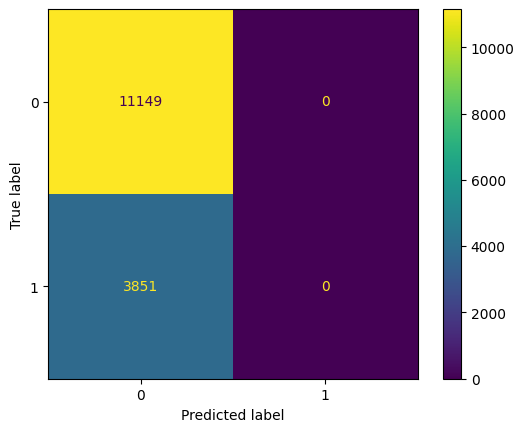

In [122]:
from sklearn.linear_model import LogisticRegression 

# instantiate the model (using the default parameters)
# 
logreg = LogisticRegression(random_state=42) 
# fit the model with data

logreg.fit(X_train, y_train)

y_pred = logreg.predict(X_test)
 
from sklearn import metrics

cnf_matrix = metrics.confusion_matrix(y_test, y_pred)
cnf_matrix

print(classification_report(y_test, y_pred))
print(accuracy_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm)
disp.plot()

# 8. Modelo com XGBClassifier

2.8342791411042945
              precision    recall  f1-score   support

         0.0       0.80      0.41      0.54     11149
         1.0       0.29      0.71      0.41      3851

    accuracy                           0.49     15000
   macro avg       0.55      0.56      0.48     15000
weighted avg       0.67      0.49      0.51     15000

Acurracy score: 0.48546666666666666
Recall da classe 1: 70.84%


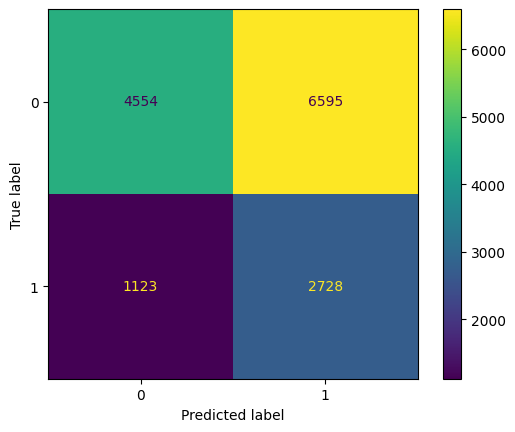

In [123]:
from xgboost import XGBClassifier
from collections import Counter
 
counter = Counter(y)
neg, pos = counter[0], counter[1]
scale = neg / pos
 
print(scale)
 
model_filter=XGBClassifier(max_depth=4,
                            n_estimators = 50,
                            learning_rate = 0.01, 
                            colsample_bylevel = 0.7, 
                            scale_pos_weight=scale, 
                            random_state = 42)
model_filter.fit(X_train,y_train)
 
#colsample_bylevel':[0.3, 0.5, 0.7, 0.9, 1],
#                    'colsample_bynode':[0.3, 0.5, 0.7, 0.9, 1],
#                    'colsample_bytree':[0.3, 0.5, 0.7, 0.9, 1]
 
y_pred=model_filter.predict(X_test)
#y_proba = model_filter.predict_proba(X_test)
#threshold = 0.45
#y_pred = (y_proba[:, 1] >= threshold).astype(int)
 

metric_filter=confusion_matrix(y_test,y_pred)
 
print (classification_report(y_test, y_pred))
 
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm)
disp.plot()
 
print(f"Acurracy score: {accuracy_score(y_test, y_pred)}")
 
# Cálculo manual do Recall da classe 1
TP = cm[1, 1]  # Verdadeiros Positivos (linha 1, coluna 1)
FN = cm[1, 0]  # Falsos Negativos (linha 1, coluna 0)
 
recall_classe_1 = TP / (TP + FN)
 
print(f"Recall da classe 1: {recall_classe_1:.2%}")

# 9. Analises do modelo

             Feature  Importance
7              IDADE    0.388882
0       ESTADO_CIVIL    0.160041
3       QUANT_CARROS    0.088075
1  QUANT_DEPENDENTES    0.078487
5      TIPO_OCUPACAO    0.073891
9        RENDA_TOTAL    0.072716
2    TIPO_RESIDENCIA    0.065488
8         TEM_CARTAO    0.047533
6            PRODUTO    0.024886
4  MESES_NO_TRABALHO    0.000000


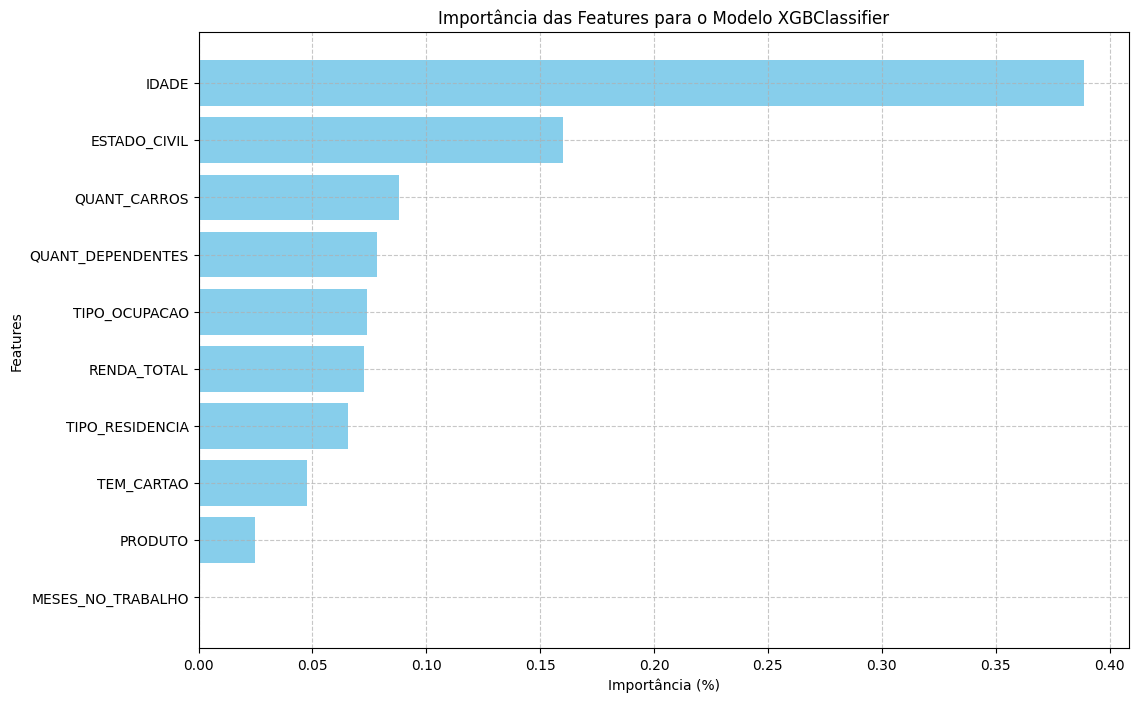

In [124]:
# Extrair a importância das features
feature_importances = model_filter.feature_importances_
 
# Se X_train é um DataFrame, usamos as colunas. Senão, criamos uma sequência numérica
try:
    feature_names = lista_headers
except:
    feature_names = [f"feature_{i}" for i in range(len(feature_importances))]
 
 
# Montar um DataFrame para organizar as importâncias
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
})
 
# Ordenar da mais importante para a menos importante
importance_df = importance_df.sort_values(by='Importance', ascending=False)
 
# Exibir o DataFrame
print(importance_df)
 
# Plotar
plt.figure(figsize=(12, 8))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='skyblue')
plt.gca().invert_yaxis()  # Deixa a mais importante no topo
plt.title('Importância das Features para o Modelo XGBClassifier')
plt.xlabel('Importância (%)')
plt.ylabel('Features')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

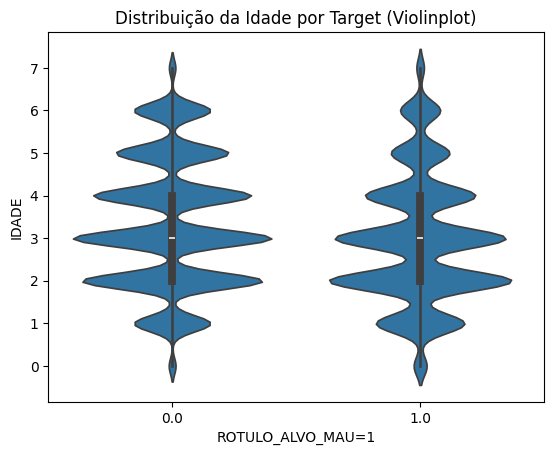

In [125]:
sns.violinplot(x='ROTULO_ALVO_MAU=1', y='IDADE', data=df_final)
plt.title('Distribuição da Idade por Target (Violinplot)')
plt.show()

In [126]:
#baseline
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
 
model = XGBClassifier(scale_pos_weight=scale, random_state=42,verbosity=0)
 
# Obtain scores of cross-validation
scores = cross_val_score(model, X, y, cv=kfold, scoring='recall')
 
# Display accuracy
print('Recall: ', scores)
 
# Display mean accuracy
print('Recall mean: ', scores.mean())

Recall:  [0.52108896 0.51572086 0.54562883 0.53489264 0.51763804]
Recall mean:  0.5269938650306749


In [127]:
def grid_search(params,
                random=False,
                X=X,
                y=y, 
                model=XGBClassifier(random_state=42, 
                                    scale_pos_weight=scale,
                                    verbosity=0, 
                                    use_label_encoder=False)):
 
    xgb = model
 
    if random:
        grid = RandomizedSearchCV(xgb, params, cv=kfold, n_jobs=-1, random_state=2, scoring='recall')
    else:
        # Instantiate GridSearchCV as grid_reg
        grid = GridSearchCV(xgb, params, cv=kfold, n_jobs=-1, scoring='recall')
 
    # Fit grid_reg on X_train and y_train
    grid.fit(X, y)
 
    # Extract best params
    best_params = grid.best_params_
 
    # Print best params
    print("Best params:", best_params)
 
    # Compute best score
    best_score = grid.best_score_
 
    # Print best score
    print("Best score: {:.5f}".format(best_score))

In [128]:
grid_search(params={'n_estimators':[50, 200, 400, 800]})

Best params: {'n_estimators': 50}
Best score: 0.54402


In [129]:
grid_search(params={'learning_rate':[0.01, 0.05, 0.2, 0.3]})

Best params: {'learning_rate': 0.01}
Best score: 0.59049


In [130]:
grid_search(params={'max_depth':[2, 3, 4, 5, 6, 7]})

Best params: {'max_depth': 2}
Best score: 0.57301


In [131]:
grid_search(params={'subsample':[0.3, 0.5, 0.7, 0.9, 1.0]})

Best params: {'subsample': 1.0}
Best score: 0.52699


In [132]:
grid_search(params={'gamma':[0.05, 0.1, 0.5, 1]})

Best params: {'gamma': 0.5}
Best score: 0.55882


In [133]:
"""grid_search(params={'subsample':[0.3, 0.5, 0.7, 0.9, 1],
                    'colsample_bylevel':[0.3, 0.5, 0.7, 0.9, 1],
                    'colsample_bynode':[0.3, 0.5, 0.7, 0.9, 1],
                    'colsample_bytree':[0.3, 0.5, 0.7, 0.9, 1],
                    'n_estimators':[50, 200, 400, 800],
                    'learning_rate':[0.01, 0.05, 0.2, 0.3],
                    'max_depth':[2, 3, 4, 5, 6, 7]}, random=True)"""

"grid_search(params={'subsample':[0.3, 0.5, 0.7, 0.9, 1],\n                    'colsample_bylevel':[0.3, 0.5, 0.7, 0.9, 1],\n                    'colsample_bynode':[0.3, 0.5, 0.7, 0.9, 1],\n                    'colsample_bytree':[0.3, 0.5, 0.7, 0.9, 1],\n                    'n_estimators':[50, 200, 400, 800],\n                    'learning_rate':[0.01, 0.05, 0.2, 0.3],\n                    'max_depth':[2, 3, 4, 5, 6, 7]}, random=True)"